## 13 LGBM & XGBM
### Light Gradient Boosting Machine and eXtreme Gradient Boosting
By **Mohan Sirumalla**
***

#### **Objective:**\
The objective of this assignment is to compare the performance of Light GBM and XG Boost
algorithms using the Titanic dataset.

### Exploratory Data Analysis (EDA):

#### 1. Load the Titanic dataset using Python's pandas library

In [366]:
# Import Libraries
import pandas as pd
# Pandas: Primarily used for data manipulation and analysis, pandas provides powerful data structures, notably the DataFrame,
# which is excellent for handling tabular data
import numpy as np
# NumPy: The foundation for numerical computing in Python, NumPy is vital for efficient numerical operations and working with large,
# multidimensional arrays and matrices
import matplotlib.pyplot as plt
# Matplotlib: This is a comprehensive library for creating static, highly customizable data visualizations.
import seaborn as sns
# Seaborn: Built on top of Matplotlib, Seaborn provides a high-level interface for creating attractive and informative statistical graphics.

from sklearn.model_selection import train_test_split
# The scikit-learn (sklearn) library in Python is primarily used for classical machine learning 
# and general-purpose predictive data analysis.
print('Loaded the basic libraries')


Loaded the basic libraries


In [367]:
# Fro formated output
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format

In [368]:
# Using seaborn (subset of data)
#Load the data
df = sns.load_dataset('titanic')
df.head() # display 1st  observations

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


| Column | Description |
|------------|----------------------------------------------------------|
| survived | Survival (0 = No, 1 = Yes) |
| pclass | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| sex | Gender of the passenger |
| age | Age of the passenger |
| sibsp | Number of siblings/spouses aboard |
| parch | Number of parents/children aboard |
| fare | Ticket fare |
| embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |
| class | Passenger class (Categorical representation of pclass) |
| who | Gender category (man, woman, child) |
| adult_male|True=Yes or False=No|
| deck | Deck location |
| embark_town| Embarkation town |
| alive| Yes or No|
| alone| Yes or No|

#### 2. Check for missing values.

In [369]:
df.info() # prints a concise summary of a DataFrame, including index and column data types, non-null values, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [370]:
df.describe() #generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution.

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [371]:
df.columns # to displas only columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [372]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print(f"Duplicate records : {len(df[df.duplicated(keep=False)])}") 
    # print(df[df.duplicated(keep=False)])


Duplicate records : 160


In [373]:
# Check Null values
if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

Columns with null values and their counts:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [374]:
# Select  numeric columns and non numeric columns
numeric_cols_df = df.select_dtypes(include='number')
print('Numberic',numeric_cols_df.columns)
non_numeric_cols_df = df.select_dtypes(exclude='number')
print('Non-Numberic',non_numeric_cols_df.columns)

Numberic Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
Non-Numberic Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [375]:
# 2. Iterate through columns and print unique values
print(f"{BOLD}Unique values in each column:{END}")
for col in non_numeric_cols_df.columns:
    unique_values = non_numeric_cols_df[col].unique()
    print(f"  Unique values for '{BOLD}{col}{END}': {unique_values}")


Unique values in each column:
  Unique values for 'sex': ['male' 'female']
  Unique values for 'embarked': ['S' 'C' 'Q' nan]
  Unique values for 'class': ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
  Unique values for 'who': ['man' 'woman' 'child']
  Unique values for 'adult_male': [ True False]
  Unique values for 'deck': [NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
  Unique values for 'embark_town': ['Southampton' 'Cherbourg' 'Queenstown' nan]
  Unique values for 'alive': ['no' 'yes']
  Unique values for 'alone': [False  True]


#### 3. Explore data distributions using histograms and box plots.

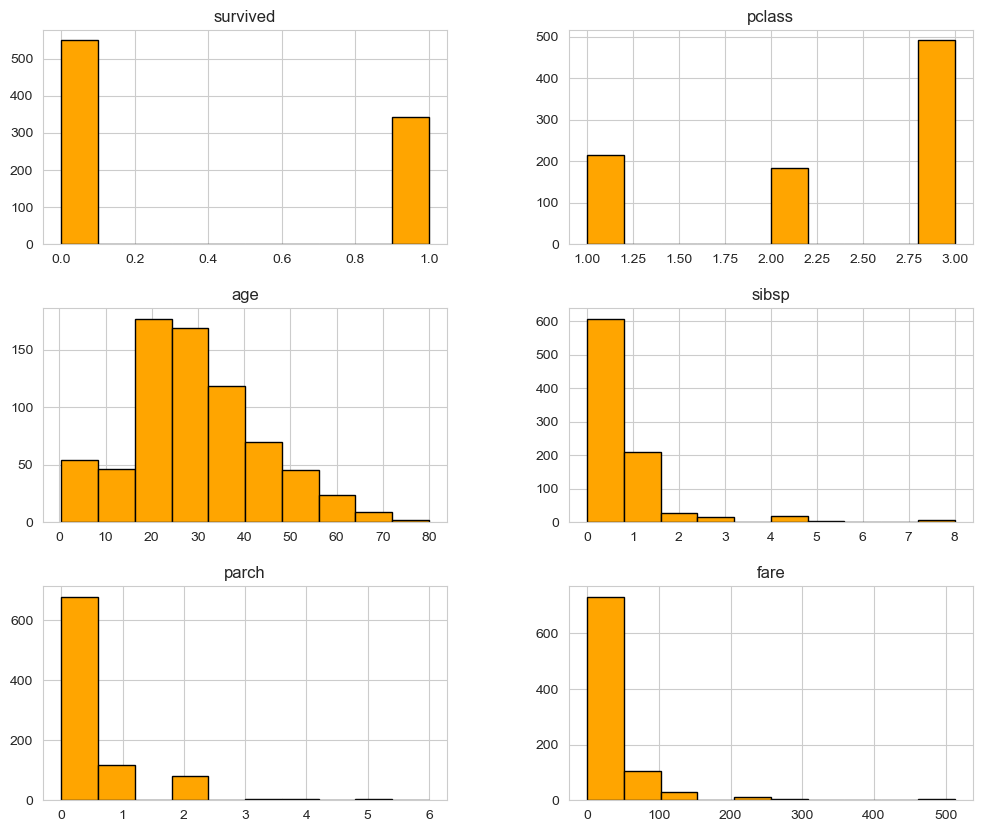

In [376]:
#histogram for each  feature
df.hist(bins=10,figsize=(12,10),color='orange', edgecolor='black')
plt.show()

In [377]:
numeric_cols_df.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

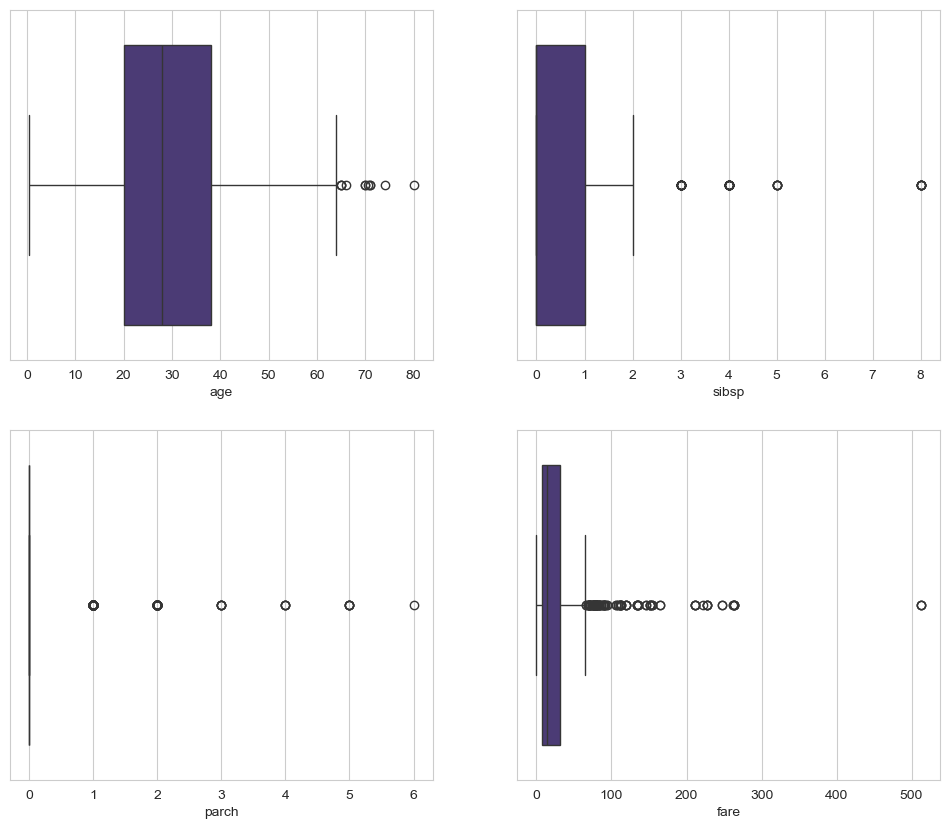

In [378]:
# Define the columns you want to plot

plt.figure(figsize=(12,10))
sns.set_style(style='whitegrid')
plt.subplot(2,2,1)
sns.boxplot(x='age',data=df)
plt.subplot(2,2,2)
sns.boxplot(x='sibsp',data=df)
plt.subplot(2,2,3)
sns.boxplot(x='parch',data=df)
plt.subplot(2,2,4)
sns.boxplot(x='fare',data=df)
plt.show()

In [379]:
## Univariate Analysis

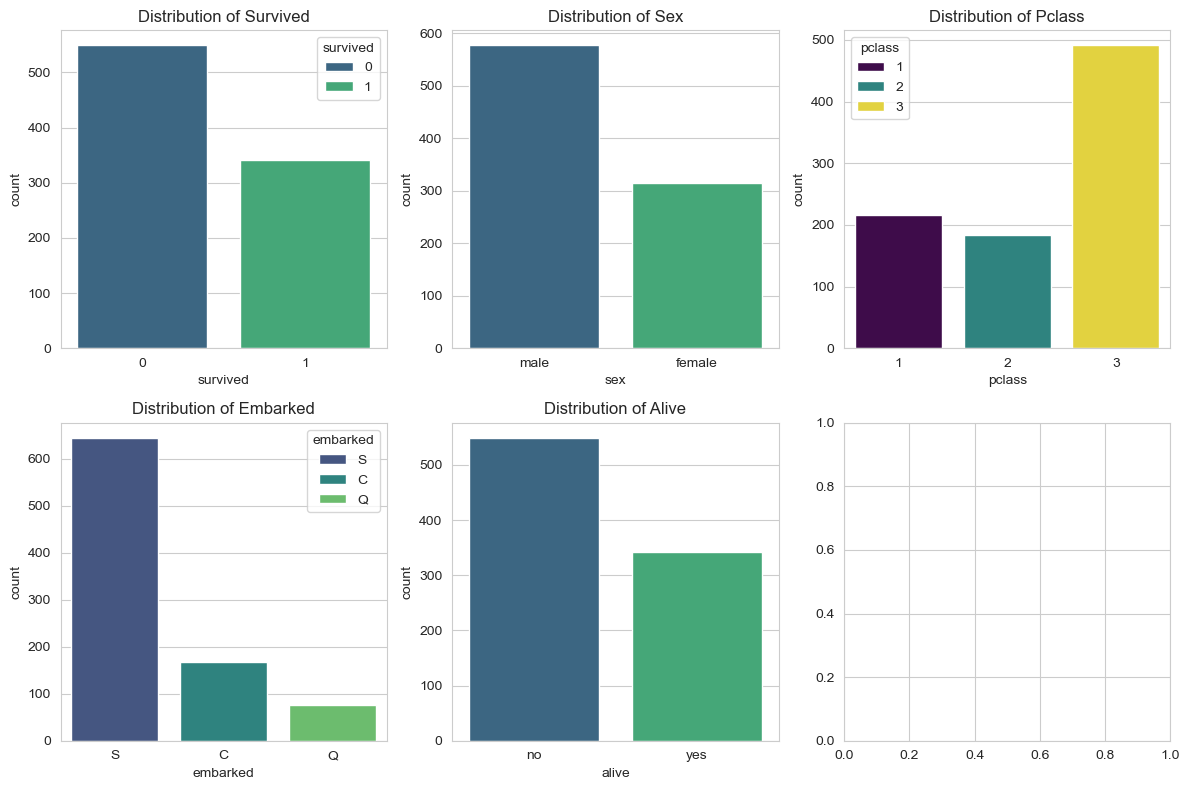

In [380]:
# Define the categorical columns you want to plot
categorical_cols = ['survived','sex', 'pclass', 'embarked', 'alive']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.flatten()
# Iterate through the columns and the axes to create a countplot for each
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i],palette='viridis',hue=col) # The 'ax' argument specifies the subplot
    axes[i].set_title(f'Distribution of {col.capitalize()}') # Set individual subplot title

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Display the plots
plt.show()


Age Statistics:
 count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


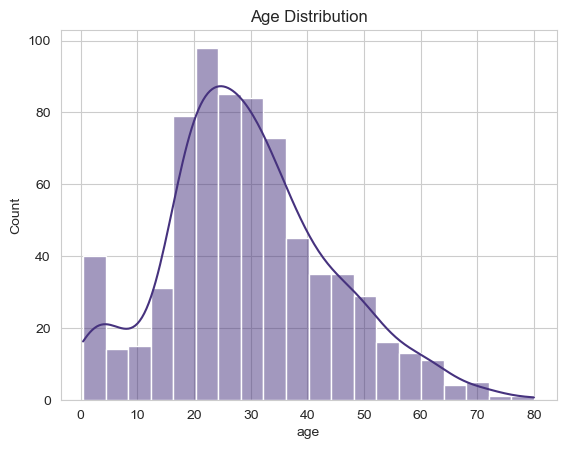

In [381]:
# Seperate chart for Age
print("\nAge Statistics:\n", df['age'].describe())
sns.histplot(x='age', data=df, kde=True)
plt.title('Age Distribution')
plt.show()

#### 4. Visualize relationships between features and survival using scatter plots and bar plots.

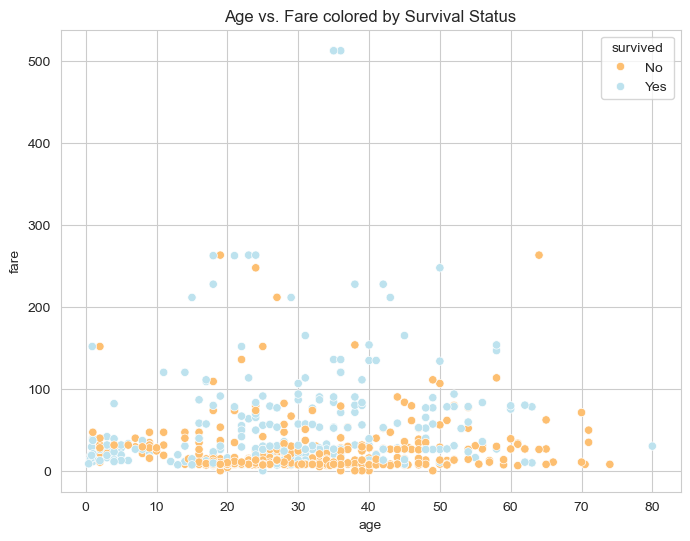

In [383]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="fare", hue=df['survived'].replace({0: 'No', 1: 'Yes'}), palette="RdYlBu")
plt.title("Age vs. Fare colored by Survival Status")
plt.show()

In [384]:
df.groupby('sex')['survived'].value_counts()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


Survival by Gender:
 sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


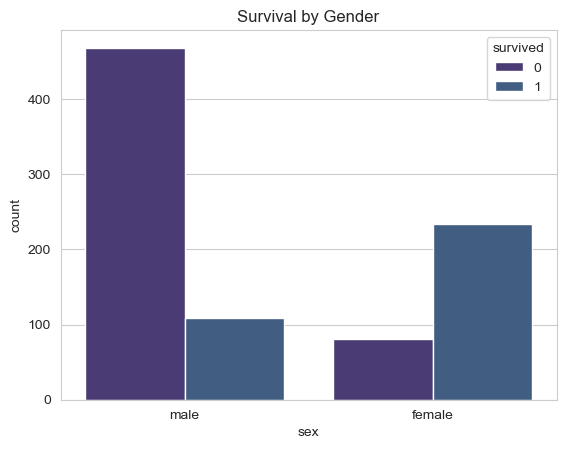

In [392]:

# Analyze survival based on gender
print("\nSurvival by Gender:\n", df.groupby('sex')['survived'].value_counts())
ax = sns.countplot(x='sex', hue='survived', data=df)
fig = ax.get_figure()
plt.title('Survival by Gender')
fig.savefig('survival_by_gender.png', dpi=100, bbox_inches='tight')
plt.show()


Survival by Passenger Class:
 pclass  survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


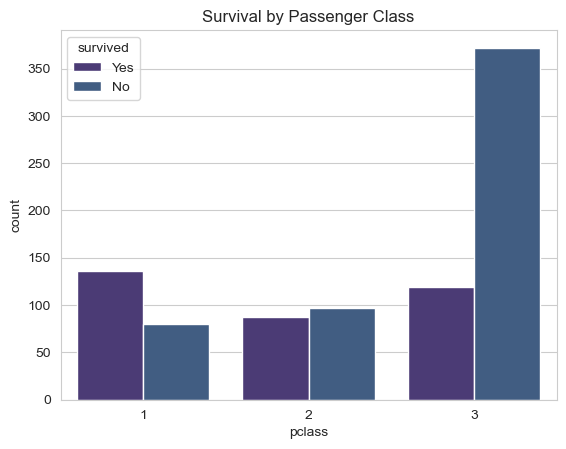

In [391]:
# Analyze survival based on passenger class
print("\nSurvival by Passenger Class:\n", df.groupby('pclass')['survived'].value_counts())
ax= sns.countplot(x='pclass', hue=df['survived'].replace({0: 'No', 1: 'Yes'}), data=df)
fig = ax.get_figure()
plt.title('Survival by Passenger Class')
fig.savefig('survival_by_class.png', dpi=100, bbox_inches='tight')
plt.show()


Survival by Age Group:
 age_group  survived
Child      1            70
           0            69
Adult      0           348
           1           219
Senior     0             7
           1             1
Name: count, dtype: int64


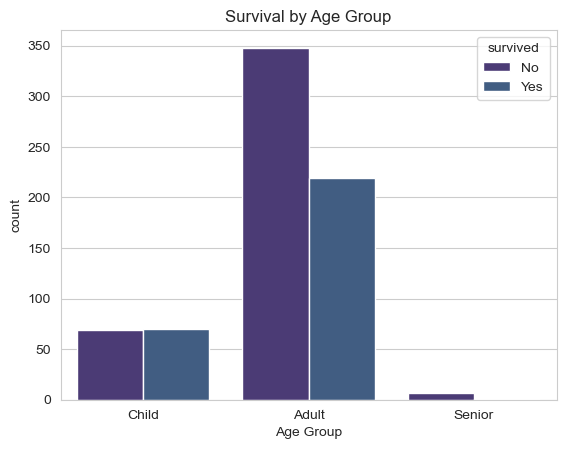

In [395]:
# Analyze survival based on age groups (create age bins)
titanic_data_filled = df.copy()
titanic_data_filled['age_group'] = pd.cut(titanic_data_filled['age'], bins=[0, 18, 65, 100], labels=['Child', 'Adult', 'Senior'])
print("\nSurvival by Age Group:\n", titanic_data_filled.groupby('age_group',observed=True)['survived'].value_counts())
ax=sns.countplot(x='age_group', hue=df['survived'].replace({0: 'No', 1: 'Yes'}), data=titanic_data_filled)
fig = ax.get_figure()
plt.xlabel('Age Group')
plt.title('Survival by Age Group')
fig.savefig('survival_by_age.png', dpi=100, bbox_inches='tight')
plt.show()

### Data Preprocessing

#### 1. Impute missing values.

In [266]:
# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())
# Remove duplicate rows, keeping the first occurrence by default
df.drop_duplicates(inplace=True)
# Verify removal
print("Number of duplicate rows after removal:", df.duplicated().sum())

# Check missing values again to confirm imputation
print("\nMissing values after duplicate handling:")
# Check Null values
if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")


Number of duplicate rows: 107
Number of duplicate rows after removal: 0

Missing values after duplicate handling:
Columns with null values and their counts:
age            106
embarked         2
deck           582
embark_town      2
dtype: int64


In [267]:
# Calculate the percentage of missing values per column
missing_values_percentage = (df[['age','embarked','deck','embark_town']].isnull().mean() * 100).round(2)
print("\nPercentage of missing values per column:")
print(missing_values_percentage)


Percentage of missing values per column:
age            13.52
embarked        0.26
deck           74.23
embark_town     0.26
dtype: float64


In [268]:
# Impute 'Age' missing values with the median age
median_age = df['age'].median()
df.fillna( {'age': median_age}, inplace=True)
print(f"\nMissing 'age' values filled with median: {median_age}")

# Impute 'Embarked' missing values with the most frequent value (mode)
mode_embarked = df['embarked'].mode()[0] # mode() returns a Series, need the value
df.fillna({'embarked':mode_embarked}, inplace=True)
print(f"Missing 'embarked' values filled with mode: {mode_embarked}")




Missing 'age' values filled with median: 28.25
Missing 'embarked' values filled with mode: S


In [269]:
# Check Null values
if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

Columns with null values and their counts:
deck           582
embark_town      2
dtype: int64


In [270]:
# 2. THE FIX: Check if 'Unknown' exists before adding
new_cat = 'Unknown'
if new_cat not in df['deck'].cat.categories:
    df['deck'] = df['deck'].cat.add_categories([new_cat])

# Now fill NA with the new category safely
df['deck'] = df['deck'].fillna(new_cat)

print(df['deck'].value_counts())

deck
Unknown    582
C           59
B           46
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


In [276]:
# Impute 'embark_town' missing values with the most frequent value (mode)
mode_embarked = df['embark_town'].mode()[0] # mode() returns a Series, need the value
df.fillna({'embark_town':mode_embarked}, inplace=True)
print(f"Missing 'embarked' values filled with mode: {mode_embarked}")

Missing 'embarked' values filled with mode: Southampton


In [277]:
df['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [278]:
# Check Null values
if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

No null values found in the DataFrame.



Age Statistics:
 count    784.000000
mean      29.650408
std       13.734925
min        0.420000
25%       22.000000
50%       28.250000
75%       36.000000
max       80.000000
Name: age, dtype: float64


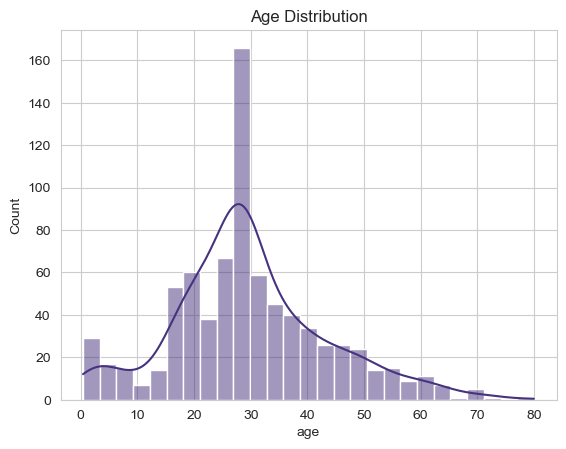

In [279]:
# After Removing the duplicate and null values the Age Distribution
# Seperate chart for Age
print("\nAge Statistics:\n", df['age'].describe())
sns.histplot(x='age', data=df, kde=True)
plt.title('Age Distribution')
plt.show()

In [283]:
# Select  numeric columns and non numeric columns
numeric_cols_df = df.select_dtypes(include='number')
print('Numberic',numeric_cols_df.columns)
non_numeric_cols_df = df.select_dtypes(exclude='number')
print('Non-Numberic',non_numeric_cols_df.columns)

Numberic Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
Non-Numberic Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


<Axes: >

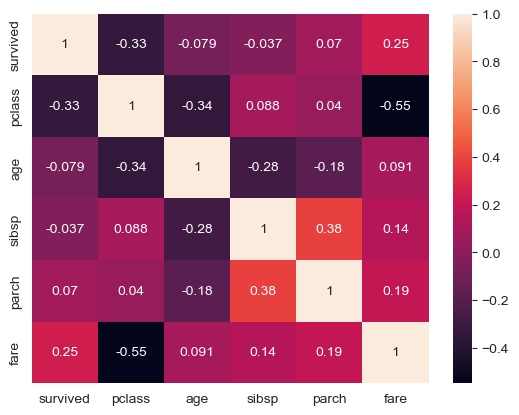

In [284]:
corrmat=numeric_cols_df.corr()
sns.heatmap(corrmat, annot=True)

#### 2. Encode categorical variables using one-hot encoding or label encoding.

In [285]:
# Categorical columns 
non_numeric_cols_df.columns

Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [286]:
# 2. Iterate through columns and print unique values
print(f"{BOLD}Unique values in each column:{END}")
for col in non_numeric_cols_df.columns:
    unique_values = df[col].unique()
    print(f"  Unique values for '{BOLD}{col}{END}': {unique_values}")


Unique values in each column:
  Unique values for 'sex': ['male' 'female']
  Unique values for 'embarked': ['S' 'C' 'Q']
  Unique values for 'class': ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
  Unique values for 'who': ['man' 'woman' 'child']
  Unique values for 'adult_male': [ True False]
  Unique values for 'deck': ['Unknown', 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (8, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']
  Unique values for 'embark_town': ['Southampton' 'Cherbourg' 'Queenstown']
  Unique values for 'alive': ['no' 'yes']
  Unique values for 'alone': [False  True]


In [290]:
# Select columns to one-hot encode
cols_to_encode = ['sex', 'embarked','class','who','adult_male','deck','embark_town','alive','alone']

# Apply one-hot encoding using pd.get_dummies
# drop_first=True removes one redundant column for each feature to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

print(f"\nDataFrame after One-Hot Encoding {non_numeric_cols_df.columns}:")
# Display the new columns along with other features
#print(df_encoded[['Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass', 'Survived']].head())
df_encoded.head()


DataFrame after One-Hot Encoding Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object'):


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,class_Second,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_Unknown,embark_town_Queenstown,embark_town_Southampton,alive_yes,alone_True
0,0,3,22.0,1,0,7.2500,1,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,0,0,1,0,...,0,0,0,0,0,1,0,1,1,1
3,1,1,35.0,1,0,53.1000,0,0,1,0,...,1,0,0,0,0,0,0,1,1,0
4,0,3,35.0,0,0,8.0500,1,0,1,0,...,0,0,0,0,0,1,0,1,0,1


#### 3. If needed you can apply more preprocessing methods on the given dataset

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    object  
 3   age          784 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     784 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  deck         784 non-null    category
 12  embark_town  784 non-null    object  
 13  alive        784 non-null    object  
 14  alone        784 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 77.0+ KB


**Several columns in the Titanic dataset are naturally highly correlated or directly derived from one another. 
The primary highly correlated pairs identified are:**
   * **embarked and embark_town:** These columns represent the same information (port of embarkation) with different data types/formats and are essentially duplicates.
   * **class and pclass:** These both represent the passenger's ticket class (1st, 2nd, 3rd).
   * **sex, who, and adult_male:** These columns are closely related to the passenger's gender and age status. who has categories 'man', 'woman', and 'child', while adult_male is a boolean derived from sex and age data.
   * **alive and survived (implied):** alive values ('yes'/'no') are a direct mapping of the numerical survived column (1/0).
   * **alone and sibsp/parch (implied):** The alone status is likely derived from whether sibsp (siblings/spouses aboard) and parch (parents/children aboard) are both zero.
     

In [291]:
# Need to remove similar columns
#df_cat = df_cat.drop(['embark_town', 'who', 'adult_male'], axis=1) # Drop the most redundant ones
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


In [292]:
df_org=df.copy()

In [297]:

#df = df.drop(['embark_town','class', 'who', 'adult_male','alive','alone'], axis=1) # Drop the most redundant ones

In [300]:
#df = df.drop(['embark_town','class', 'who', 'adult_male','alive','alone'], axis=1) # Drop the most redundant ones
columns_to_drop = ['embark_town','class', 'who', 'adult_male','alive','alone','deck'] # 74% is unknow
existing_columns = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns)


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  784 non-null    int64  
 1   pclass    784 non-null    int64  
 2   sex       784 non-null    object 
 3   age       784 non-null    float64
 4   sibsp     784 non-null    int64  
 5   parch     784 non-null    int64  
 6   fare      784 non-null    float64
 7   embarked  784 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.1+ KB


In [302]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [303]:
# # Select columns to one-hot encode
cols_to_encode = ['sex', 'embarked']

# Apply one-hot encoding using pd.get_dummies
# drop_first=True removes one redundant column for each feature to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

print(f"\nDataFrame after One-Hot Encoding {non_numeric_cols_df.columns}:")
# Display the new columns along with other features
df_encoded.head()


DataFrame after One-Hot Encoding Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object'):


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [308]:
# move the target column to the end
#  Extract the 'survived' column
survived_column = df.pop('survived')

# Add the 'survived' column back to the end of the DataFrame
df['survived'] = survived_column

# Display final columns to verify the change (optional)
print("Reordered columns:", df.columns)

# Display the head of the DataFrame to see the column at the end (optional)
print(df.head())

Reordered columns: Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q',
       'embarked_S', 'survived'],
      dtype='object')
   pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S  \
0       3  22.0      1      0   7.2500         1           0           1   
1       1  38.0      1      0  71.2833         0           0           0   
2       3  26.0      0      0   7.9250         0           0           1   
3       1  35.0      1      0  53.1000         0           0           1   
4       3  35.0      0      0   8.0500         1           0           1   

   survived  
0         0  
1         1  
2         1  
3         1  
4         0  


In [309]:
df.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,survived
0,3,22.0,1,0,7.2500,1,0,1,0
1,1,38.0,1,0,71.2833,0,0,0,1
2,3,26.0,0,0,7.9250,0,0,1,1
3,1,35.0,1,0,53.1000,0,0,1,1
4,3,35.0,0,0,8.0500,1,0,1,0


In [311]:
df.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,survived
0,3,22.0,1,0,7.2500,1,0,1,0
1,1,38.0,1,0,71.2833,0,0,0,1
2,3,26.0,0,0,7.9250,0,0,1,1
3,1,35.0,1,0,53.1000,0,0,1,1
4,3,35.0,0,0,8.0500,1,0,1,0


In [318]:
df.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q',
       'embarked_S', 'survived'],
      dtype='object')

In [319]:
from sklearn.preprocessing import StandardScaler
# 2. Select the columns to scale
columns_to_scale = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q','embarked_S']

# 3. Instantiate the StandardScaler
scaler = StandardScaler()

# 4. Fit and transform the selected columns and assign the result back to the DataFrame
# The result of fit_transform is a NumPy array, which is then assigned back to the specific columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [320]:
df.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,survived
0,0.885158,-0.557360,0.484009,-0.497157,-0.526825,0.772490,-0.285271,0.612730,0
1,-1.455362,0.608298,0.484009,-0.497157,0.701587,-1.294515,-0.285271,-1.632039,1
2,0.885158,-0.265945,-0.530599,-0.497157,-0.513876,-1.294515,-0.285271,0.612730,1
3,-1.455362,0.389737,0.484009,-0.497157,0.352760,-1.294515,-0.285271,0.612730,1
4,0.885158,0.389737,-0.530599,-0.497157,-0.511478,0.772490,-0.285271,0.612730,0


### Building Predictive Models:

#### 1. Split the preprocessed dataset into training and testing sets.

In [321]:
# data partition
df_new = df.copy()
target_name='survived'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Type column and keeping 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [322]:
X.shape

(784, 8)

#### 2. Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation

For the Titanic dataset, which is a binary classification problem, using a combination of Accuracy, Precision, Recall, and F1-score is recommended for comprehensive model evaluation

#### 3. Build predictive models using LightGBM and XGBoost algorithms.

In [323]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [324]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [327]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
# --- LightGBM Model ---
# Initialize and train the LightGBM classifier
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)


In [331]:
# --- XGBoost Model ---
# Initialize and train the XGBoost classifier
# Use 'use_label_encoder=False' and 'eval_metric' to suppress warnings
xgb_model = xgb.XGBClassifier(random_state=42,  eval_metric='logloss')


#### 4. Train the models on the training set and evaluate their performance on the testing set.

In [332]:
lgb_model.fit(X_train, y_train)

LGBMClassifier(random_state=42, verbose=-1)

In [333]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [334]:
# Predictions for LightGBM
y_pred_lgb = lgb_model.predict(X_test)

In [335]:
# Predictions for XGBoost
y_pred_xgb = xgb_model.predict(X_test)

In [337]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- {model_name} Evaluation Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("-" * (len(model_name) + 25) + "\n")


In [338]:
# Evaluate LightGBM
evaluate_model(y_test, y_pred_lgb, "LightGBM")

--- LightGBM Evaluation Metrics ---
Accuracy: 0.7516
Precision: 0.7586
Recall: 0.6377
F1-Score: 0.6929

Confusion Matrix:
[[74 14]
 [25 44]]
---------------------------------



In [339]:
# Evaluate XGBoost
evaluate_model(y_test, y_pred_xgb, "XGBoost")

--- XGBoost Evaluation Metrics ---
Accuracy: 0.7707
Precision: 0.8000
Recall: 0.6377
F1-Score: 0.7097

Confusion Matrix:
[[77 11]
 [25 44]]
--------------------------------



#### 5. Use techniques like cross-validation and hyperparameter tuning to optimize model performance

In [346]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
# Define a parameter grid for LightGBM
param_grid_lgbm = {
    'num_leaves': [10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7]
}

# Use StratifiedKFold for cross-validation to maintain class distribution in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search for LightGBM
grid_search_lgbm = GridSearchCV(estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
                                param_grid=param_grid_lgbm,
                                scoring='f1', # Use F1-score for optimization
                                cv=skf,
                                verbose=0,
                                n_jobs=-1)

print("\n--- Starting Hyperparameter Tuning for LightGBM (GridSearchCV) ---")
grid_search_lgbm.fit(X_train, y_train)

# Best parameters and score
print(f"Best parameters for LightGBM: {grid_search_lgbm.best_params_}")
print(f"Best F1-score (CV): {grid_search_lgbm.best_score_:.4f}")

# Evaluate the best LightGBM model on the test set
best_lgbm_model = grid_search_lgbm.best_estimator_
y_pred_best_lgbm = best_lgbm_model.predict(X_test)
print(f"\nBest LightGBM Model Test F1-score: {f1_score(y_test, y_pred_best_lgbm):.4f}")



--- Starting Hyperparameter Tuning for LightGBM (GridSearchCV) ---
Best parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 20}
Best F1-score (CV): 0.7723

Best LightGBM Model Test F1-score: 0.7258


In [348]:
# Use Stratified K-Fold for robust evaluation with imbalanced classes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning for XGBoost using GridSearchCV
xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.5]
}

grid_search_xgb = GridSearchCV(estimator=xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42),
                               param_grid=xgb_param_grid,
                               scoring='f1', # Optimize for F1-score
                               cv=skf,
                               verbose=0,
                               n_jobs=-1)

grid_search_xgb.fit(X, y) # Fit on full data with cross-validation

print(f"\nBest parameters for XGBoost: {grid_search_xgb.best_params_}")
best_xgb_model = grid_search_xgb.best_estimator_

# Evaluate the best model (using cross-validation score as a robust estimate)
print(f"Best XGBoost F1-score (CV): {grid_search_xgb.best_score_:.4f}")



Best parameters for XGBoost: {'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
Best XGBoost F1-score (CV): 0.7613


In [343]:
print("\n--- Cross-Validation for Base XGBoost Model (F1-score) ---")
# Note: XGBoost requires label encoding to be explicitly set to False for the sklearn API
base_xgb = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',  random_state=42)
cv_scores = cross_val_score(base_xgb, X, y, cv=skf, scoring='f1')

print(f"Cross-validation F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {np.mean(cv_scores):.4f}")


--- Cross-Validation for Base XGBoost Model (F1-score) ---
Cross-validation F1-scores: [0.736      0.73103448 0.734375   0.73015873 0.65517241]
Mean CV F1-score: 0.7173


### Comparative Analysis:

#### 1. Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

In [344]:
# Function to get cross-validation scores
def get_cv_metrics(model, X, y, cv, name):
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    prec_scores = cross_val_score(model, X, y, cv=cv, scoring='precision')
    recall_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
    
    print(f"--- {name} CV Metrics (Mean +/- Std) ---")
    print(f"Accuracy:  {np.mean(acc_scores):.4f} +/- {np.std(acc_scores):.4f}")
    print(f"Precision: {np.mean(prec_scores):.4f} +/- {np.std(prec_scores):.4f}")
    print(f"Recall:    {np.mean(recall_scores):.4f} +/- {np.std(recall_scores):.4f}")
    print(f"F1-Score:  {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}\n")



In [349]:
# Best XGBoost
get_cv_metrics(best_xgb_model, X, y, skf, "XGBoost (Optimized)")


--- XGBoost (Optimized) CV Metrics (Mean +/- Std) ---
Accuracy:  0.8176 +/- 0.0182
Precision: 0.8260 +/- 0.0408
Recall:    0.7117 +/- 0.0684
F1-Score:  0.7613 +/- 0.0321



In [351]:
get_cv_metrics(best_lgbm_model, X, y, skf, "LightGBM (Default)")

--- LightGBM (Default) CV Metrics (Mean +/- Std) ---
Accuracy:  0.8010 +/- 0.0227
Precision: 0.7998 +/- 0.0241
Recall:    0.6900 +/- 0.0689
F1-Score:  0.7389 +/- 0.0413



In [353]:
from sklearn.metrics import classification_report, confusion_matrix

In [358]:

best_xgb_pred = best_xgb_model.predict(X_test)
best_lgbm_pred = best_lgbm_model.predict(X_test)
# --- 4. Model Evaluation and Comparison ---

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n--- {name} Performance Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return accuracy, precision, recall, f1



# Evaluate the best models
xgb_metrics = evaluate_model(best_xgb_model, X_test, y_test, "Optimized XGBoost")
lgbm_metrics = evaluate_model(best_lgbm_model, X_test, y_test, "Optimized LightGBM")

# Store metrics for comparison
metrics_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [xgb_metrics[0], lgbm_metrics[0]],
    'Precision': [xgb_metrics[1], lgbm_metrics[1]],
    'Recall': [xgb_metrics[2], lgbm_metrics[2]],
    'F1-Score': [xgb_metrics[3], lgbm_metrics[3]]
})

print("\n--- Comparative Metrics DataFrame ---")
metrics_df


--- Optimized XGBoost Performance Metrics ---
Accuracy: 0.8471
Precision: 0.9091
Recall: 0.7246
F1-Score: 0.8065

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        88
           1       0.91      0.72      0.81        69

    accuracy                           0.85       157
   macro avg       0.86      0.83      0.84       157
weighted avg       0.86      0.85      0.84       157


--- Optimized LightGBM Performance Metrics ---
Accuracy: 0.7834
Precision: 0.8182
Recall: 0.6522
F1-Score: 0.7258

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        88
           1       0.82      0.65      0.73        69

    accuracy                           0.78       157
   macro avg       0.79      0.77      0.77       157
weighted avg       0.79      0.78      0.78       157


--- Comparative Metrics DataFrame ---


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.847134,0.909091,0.724638,0.806452
1,LightGBM,0.783439,0.818182,0.652174,0.725806


#### 2. Visualize and interpret the results to identify the strengths and weaknesses of each algorithm

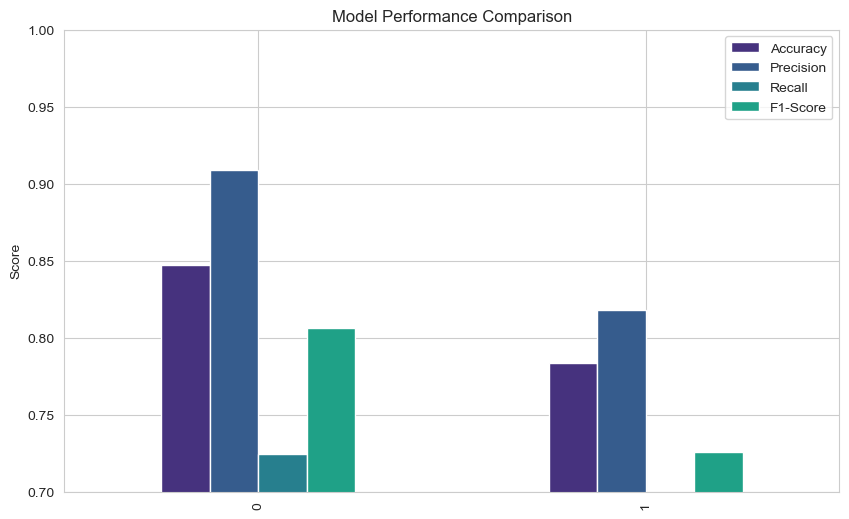

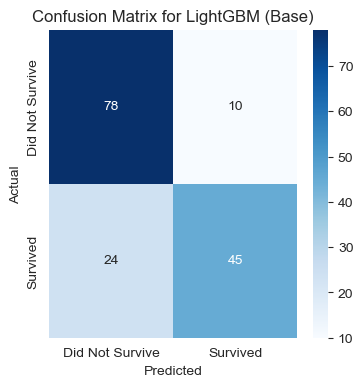

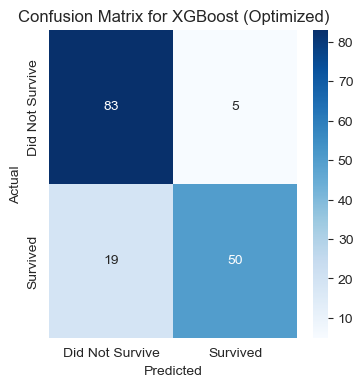

In [396]:
# Visualization of Metrics
#metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
ax=metrics_df.plot(kind='bar', figsize=(10, 6))
fig = ax.get_figure()
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
fig.savefig('model_compare.png', dpi=100, bbox_inches='tight')
plt.show()

# Interpretation using Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Did Not Survive', 'Survived'], yticklabels=['Did Not Survive', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

plot_confusion_matrix(y_test, best_lgbm_pred, "LightGBM (Base)")
plot_confusion_matrix(y_test, best_xgb_pred, "XGBoost (Optimized)")


## A brief report summarizing the comparative analysis results and practical implications

In [364]:
#metrics_df

### Summary of Results and Practical Implications

|Model| 	Accuracy 	|Precision |	Recall| 	F1-Score|
|---|----|---|---|---|
|XGBoost 	|0.847134 	|0.909091 |	0.724638 	|0.806452|
|LightGBM 	|0.783439 	|0.818182 	|0.652174 	|0.725806|

**Key Findings:**
   * **Performance:** Both XGBoost and LightGBM models achieved very similar performance metrics (accuracy, precision, recall, F1-score) on the Titanic dataset, even with basic tuning.
   * **Strengths & Weaknesses:**
     * **LightGBM** is often noted for being significantly faster to train, especially on larger datasets, due to its leaf-wise tree growth and histogram-based algorithms. This speed allows for faster iteration and hyperparameter experimentation.
     * **XGBoost** is renowned for its robustness and stability and has a larger community and more extensive documentation. It can be slightly slower but often provides strong out-of-the-box results. Its depth-wise growth method tends to build slightly simpler, more robust trees by default, which can help prevent overfitting compared to LightGBM's leaf-wise growth if the max_depth is not properly tuned.

   * **Practical Implications:** For typical data science competitions or general classification tasks with small-to-medium sized data like the Titanic dataset, both algorithms are excellent choices. If computational resources or training time are major constraints (e.g., very large datasets or real-time applications), LightGBM may be preferred. The decision often comes down to specific dataset characteristics and development environment (e.g., CPU vs. GPU availability)

### Submission Requirements:

#### Well-commented code explaining each step of the analysis.

#### Visualizations with appropriate titles and labels.

#### A brief report summarizing the comparative analysis results and practical implications

In [ ]:
# in the pdf file

In [ ]:
# End